# Notebook 4: Agent 3 — Skill Gap Analysis & Recommendations
## The Core Intelligence Layer

This notebook implements the heart of the system:
1. **Skill matching classification**: Matched, partially matched, and missing skills
2. **Skill gap ranking**: Priority scoring based on frequency, importance, and semantic distance
3. **Personalized recommendation generation**: Actionable career improvement suggestions
4. **End-to-end gap analysis pipeline**


In [1]:
from google.colab import drive
import os

# 1. Mount the Drive
drive.mount('/content/drive')

# 2. Define your actual Drive project path
drive_path = '/content/drive/MyDrive/Colab Notebooks/DM_project_1'

# 3. Create the symbolic links
# This links the 'data', 'models', and 'outputs' folders from Drive to your local Colab env
folders = ['data', 'models', 'outputs']

for folder in folders:
    source = os.path.join(drive_path, folder)
    link = f'/content/{folder}'

    # Remove existing local folder/link if it exists to avoid errors
    if os.path.exists(link) or os.path.islink(link):
        !rm -rf {link}

    # Create the link (Shortcut)
    !ln -s "{source}" "{link}"
    print(f"✅ Linked local '{folder}/' to Drive '{folder}/'")

Mounted at /content/drive
✅ Linked local 'data/' to Drive 'data/'
✅ Linked local 'models/' to Drive 'models/'
✅ Linked local 'outputs/' to Drive 'outputs/'


In [2]:
# ============================================================
# Setup
# ============================================================
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Load everything from previous notebooks
df_jobs = pd.read_csv('data/processed/jobs_with_skills.csv')
df_resumes = pd.read_csv('data/processed/resumes_with_skills.csv')

with open('data/processed/column_config.json') as f:
    col_config = json.load(f)
with open('data/processed/skill_category_map.json') as f:
    skill_category_map = json.load(f)
with open('data/processed/extraction_results.pkl', 'rb') as f:
    extraction_data = pickle.load(f)
with open('data/processed/embeddings_data.pkl', 'rb') as f:
    emb_data = pickle.load(f)

df_jobs['skills_list'] = df_jobs['extracted_skills'].apply(json.loads)
df_resumes['skills_list'] = df_resumes['extracted_skills'].apply(json.loads)

skill_embeddings = emb_data['skill_embeddings_dict']
sim_combined = emb_data['sim_combined']
job_skill_freq = extraction_data['job_skill_freq']

title_col = col_config['jobs_title_col']
cat_col = col_config['resume_cat_col']

print(f"Loaded {len(df_jobs)} jobs, {len(df_resumes)} resumes")
print(f"Skill embeddings: {len(skill_embeddings)} skills")


Loaded 813 jobs, 106 resumes
Skill embeddings: 121 skills


## 1. Agent 3: Skill Gap Analyzer

The agent classifies each required job skill relative to the resume:
- **Matched**: Exact canonical skill present in resume
- **Partially matched**: Resume has a semantically similar skill (cosine sim > threshold)
- **Missing**: No close match found in resume

Missing skills are then ranked by a composite priority score.


In [3]:
# ============================================================
# 1. Skill Gap Analyzer (Agent 3)
# ============================================================

class SkillGapAnalyzer:
    """
    Agent 3: Analyzes skill gaps between a resume and job description.
    Classifies skills as matched/partial/missing and generates ranked recommendations.
    """

    # Thresholds for skill matching
    EXACT_MATCH_THRESHOLD = 1.0       # Exact canonical match
    PARTIAL_MATCH_THRESHOLD = 0.55    # Semantic similarity threshold for partial match
    HIGH_PRIORITY_THRESHOLD = 0.7     # Priority score threshold for "high priority" skills

    def __init__(self, skill_embeddings, skill_category_map, job_skill_freq, total_jobs):
        self.skill_embeddings = skill_embeddings
        self.skill_category_map = skill_category_map
        self.job_skill_freq = job_skill_freq
        self.total_jobs = total_jobs

    def _get_embedding(self, skill):
        """Get embedding for a skill, returning None if not found."""
        return self.skill_embeddings.get(skill)

    def _semantic_similarity(self, skill_a, skill_b):
        """Compute cosine similarity between two skills."""
        emb_a = self._get_embedding(skill_a)
        emb_b = self._get_embedding(skill_b)
        if emb_a is None or emb_b is None:
            return 0.0
        return float(cosine_similarity(
            emb_a.reshape(1, -1), emb_b.reshape(1, -1)
        )[0, 0])

    def _find_best_match(self, job_skill, resume_skills):
        """Find the best matching resume skill for a given job skill."""
        if job_skill in resume_skills:
            return job_skill, 1.0, 'exact'

        best_match = None
        best_sim = 0.0
        for r_skill in resume_skills:
            # Check same category first (boost)
            same_cat = (self.skill_category_map.get(job_skill) ==
                       self.skill_category_map.get(r_skill))
            sim = self._semantic_similarity(job_skill, r_skill)
            if same_cat:
                sim = min(1.0, sim * 1.1)  # Small boost for same category
            if sim > best_sim:
                best_sim = sim
                best_match = r_skill

        if best_sim >= self.PARTIAL_MATCH_THRESHOLD:
            return best_match, best_sim, 'partial'
        return None, best_sim, 'missing'

    def _compute_priority_score(self, skill, similarity_distance):
        """
        Compute priority score for a missing/partially-matched skill.
        Higher score = more important to learn.

        Components:
        - Frequency: How often does this skill appear across all job postings?
        - Importance: Is this a core technical skill or a soft skill?
        - Semantic distance: How far is the closest resume skill?
        """
        # Frequency score (0-1): proportion of jobs requiring this skill
        freq = self.job_skill_freq.get(skill, 0)
        freq_score = min(1.0, freq / (self.total_jobs * 0.3))

        # Importance score based on category
        category = self.skill_category_map.get(skill, 'unknown')
        importance_weights = {
            'programming_languages': 0.9,
            'machine_learning': 0.95,
            'ml_frameworks': 0.85,
            'data_engineering': 0.85,
            'data_analysis': 0.8,
            'cloud_devops': 0.75,
            'specialized': 0.8,
            'soft_skills': 0.5,
        }
        importance_score = importance_weights.get(category, 0.6)

        # Distance score: how far is this skill from what you already know?
        # Lower similarity = higher gap = higher priority
        distance_score = 1.0 - similarity_distance

        # Weighted combination
        priority = (0.35 * freq_score +
                   0.30 * importance_score +
                   0.35 * distance_score)

        return round(priority, 4)

    def analyze(self, resume_skills, job_skills, job_title=''):
        """
        Perform full skill gap analysis between a resume and a job.

        Args:
            resume_skills: list of canonical skills from resume
            job_skills: list of canonical skills from job description
            job_title: optional job title for context

        Returns:
            dict with matched, partial, missing skills and recommendations
        """
        resume_set = set(resume_skills)
        job_set = set(job_skills)

        matched = []
        partial_matches = []
        missing = []

        for job_skill in job_set:
            best_match, sim, match_type = self._find_best_match(job_skill, resume_set)

            if match_type == 'exact':
                matched.append({
                    'skill': job_skill,
                    'category': self.skill_category_map.get(job_skill, 'unknown'),
                })
            elif match_type == 'partial':
                partial_matches.append({
                    'job_skill': job_skill,
                    'resume_match': best_match,
                    'similarity': round(sim, 4),
                    'category': self.skill_category_map.get(job_skill, 'unknown'),
                })
            else:
                priority = self._compute_priority_score(job_skill, sim)
                missing.append({
                    'skill': job_skill,
                    'category': self.skill_category_map.get(job_skill, 'unknown'),
                    'closest_resume_skill': best_match,
                    'closest_similarity': round(sim, 4),
                    'priority_score': priority,
                    'frequency_in_jobs': self.job_skill_freq.get(job_skill, 0),
                })

        # Sort missing by priority (highest first)
        missing.sort(key=lambda x: x['priority_score'], reverse=True)

        # Compute coverage metrics
        total_required = len(job_set)
        coverage_rate = len(matched) / total_required if total_required > 0 else 0
        partial_rate = len(partial_matches) / total_required if total_required > 0 else 0

        # Generate recommendations
        recommendations = self._generate_recommendations(
            matched, partial_matches, missing, job_title, resume_skills
        )

        return {
            'job_title': job_title,
            'total_job_skills': total_required,
            'matched': matched,
            'partial_matches': partial_matches,
            'missing': missing,
            'num_matched': len(matched),
            'num_partial': len(partial_matches),
            'num_missing': len(missing),
            'coverage_rate': round(coverage_rate, 4),
            'partial_coverage_rate': round(partial_rate, 4),
            'total_coverage_rate': round(coverage_rate + partial_rate, 4),
            'recommendations': recommendations,
        }

    def _generate_recommendations(self, matched, partial, missing, job_title, resume_skills):
        """Generate actionable recommendations based on the gap analysis."""
        recs = []

        # High-priority missing skills
        high_priority = [m for m in missing if m['priority_score'] >= self.HIGH_PRIORITY_THRESHOLD]
        if high_priority:
            skills_str = ', '.join([m['skill'] for m in high_priority[:5]])
            recs.append({
                'type': 'critical_gaps',
                'priority': 'high',
                'message': f"Critical skill gaps for {job_title or 'this role'}: {skills_str}. "
                          f"These skills appear frequently in similar job postings and are "
                          f"core technical requirements.",
                'skills': [m['skill'] for m in high_priority[:5]],
            })

        # Partial matches that could be strengthened
        strong_partials = [p for p in partial if p['similarity'] < 0.75]
        if strong_partials:
            for p in strong_partials[:3]:
                recs.append({
                    'type': 'strengthen',
                    'priority': 'medium',
                    'message': f"Your '{p['resume_match']}' skill is related to the required "
                              f"'{p['job_skill']}'. Consider deepening this expertise.",
                    'skills': [p['job_skill']],
                })

        # Category-level gaps
        missing_categories = Counter([m['category'] for m in missing])
        for cat, count in missing_categories.most_common(2):
            if count >= 2:
                cat_skills = [m['skill'] for m in missing if m['category'] == cat][:3]
                recs.append({
                    'type': 'category_gap',
                    'priority': 'medium',
                    'message': f"You have multiple gaps in '{cat}': {', '.join(cat_skills)}. "
                              f"Consider a focused learning path in this area.",
                    'skills': cat_skills,
                })

        # Strengths acknowledgment
        if matched:
            matched_str = ', '.join([m['skill'] for m in matched[:5]])
            recs.append({
                'type': 'strengths',
                'priority': 'info',
                'message': f"Strong matches: {matched_str}. These align well with the role.",
                'skills': [m['skill'] for m in matched[:5]],
            })

        return recs


# Initialize Agent 3
analyzer = SkillGapAnalyzer(
    skill_embeddings=skill_embeddings,
    skill_category_map=skill_category_map,
    job_skill_freq=job_skill_freq,
    total_jobs=len(df_jobs),
)

print("✅ Agent 3 (Skill Gap Analyzer) initialized!")


✅ Agent 3 (Skill Gap Analyzer) initialized!


## 2. Run Gap Analysis Across Dataset

We run the analyzer for each resume against its top-matching jobs to generate comprehensive gap reports.


In [4]:
# ============================================================
# 2. Run Full Gap Analysis
# ============================================================

# For each resume, analyze against its top-3 matching jobs
all_analyses = []
n_top_jobs = 3

print(f"Running gap analysis: {len(df_resumes)} resumes × top-{n_top_jobs} jobs each...")
print()

for i in range(len(df_resumes)):
    resume_skills = df_resumes.iloc[i]['skills_list']
    top_job_indices = sim_combined[i].argsort()[-n_top_jobs:][::-1]

    for rank, j in enumerate(top_job_indices):
        job_skills = df_jobs.iloc[j]['skills_list']
        job_title = df_jobs.iloc[j].get(title_col, 'Unknown')

        result = analyzer.analyze(resume_skills, job_skills, job_title)
        result['resume_idx'] = i
        result['job_idx'] = int(j)
        result['match_rank'] = rank + 1
        result['resume_category'] = df_resumes.iloc[i].get(cat_col, 'Unknown')
        result['similarity_score'] = float(sim_combined[i, j])
        all_analyses.append(result)

    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{len(df_resumes)} resumes...")

print(f"\n✅ Gap analysis complete! {len(all_analyses)} resume-job pairs analyzed.")

# Convert to DataFrame for analysis
analysis_df = pd.DataFrame([{
    'resume_idx': a['resume_idx'],
    'job_idx': a['job_idx'],
    'job_title': a['job_title'],
    'resume_category': a['resume_category'],
    'match_rank': a['match_rank'],
    'similarity_score': a['similarity_score'],
    'total_job_skills': a['total_job_skills'],
    'num_matched': a['num_matched'],
    'num_partial': a['num_partial'],
    'num_missing': a['num_missing'],
    'coverage_rate': a['coverage_rate'],
    'partial_coverage_rate': a['partial_coverage_rate'],
    'total_coverage_rate': a['total_coverage_rate'],
} for a in all_analyses])

print(f"\nOverall statistics:")
print(f"  Avg exact match coverage: {analysis_df['coverage_rate'].mean():.1%}")
print(f"  Avg partial match rate:   {analysis_df['partial_coverage_rate'].mean():.1%}")
print(f"  Avg total coverage:       {analysis_df['total_coverage_rate'].mean():.1%}")
print(f"  Avg missing skills:       {analysis_df['num_missing'].mean():.1f}")


Running gap analysis: 106 resumes × top-3 jobs each...


✅ Gap analysis complete! 318 resume-job pairs analyzed.

Overall statistics:
  Avg exact match coverage: 38.5%
  Avg partial match rate:   6.2%
  Avg total coverage:       44.7%
  Avg missing skills:       5.5


In [5]:
# ============================================================
# 3. Detailed Example Gap Reports
# ============================================================

print("=" * 80)
print("DETAILED GAP ANALYSIS EXAMPLES")
print("=" * 80)

# Show 3 diverse examples
shown = 0
seen_categories = set()
for a in all_analyses:
    if a['match_rank'] == 1 and a['resume_category'] not in seen_categories:
        seen_categories.add(a['resume_category'])
        print(f"\n{'─'*80}")
        print(f"RESUME: Category = {a['resume_category']}")
        print(f"MATCHED JOB: {a['job_title']} (similarity: {a['similarity_score']:.3f})")
        print(f"{'─'*80}")

        print(f"\n📊 Coverage: {a['coverage_rate']:.0%} exact, "
              f"{a['partial_coverage_rate']:.0%} partial, "
              f"{a['num_missing']} missing out of {a['total_job_skills']} required")

        if a['matched']:
            print(f"\n✅ Matched skills ({a['num_matched']}):")
            for m in a['matched'][:8]:
                print(f"   • {m['skill']} [{m['category']}]")

        if a['partial_matches']:
            print(f"\n🔶 Partial matches ({a['num_partial']}):")
            for p in a['partial_matches'][:5]:
                print(f"   • {p['job_skill']} ← your '{p['resume_match']}' "
                      f"(sim: {p['similarity']:.2f})")

        if a['missing']:
            print(f"\n❌ Missing skills ({a['num_missing']}):")
            for m in a['missing'][:8]:
                print(f"   • {m['skill']} [{m['category']}] "
                      f"(priority: {m['priority_score']:.2f}, "
                      f"in {m['frequency_in_jobs']} jobs)")

        if a['recommendations']:
            print(f"\n💡 Recommendations:")
            for r in a['recommendations'][:4]:
                icon = {'high': '🔴', 'medium': '🟡', 'info': '🟢'}.get(r['priority'], '⚪')
                print(f"   {icon} [{r['type']}] {r['message']}")

        shown += 1
        if shown >= 3:
            break


DETAILED GAP ANALYSIS EXAMPLES

────────────────────────────────────────────────────────────────────────────────
RESUME: Category = Data Science
MATCHED JOB: Data Scientist (similarity: 0.569)
────────────────────────────────────────────────────────────────────────────────

📊 Coverage: 48% exact, 4% partial, 11 missing out of 23 required

✅ Matched skills (11):
   • docker [cloud_devops]
   • sql [programming_languages]
   • deep learning [machine_learning]
   • time series [machine_learning]
   • python [programming_languages]
   • apache kafka [data_engineering]
   • scikit-learn [ml_frameworks]
   • machine learning [machine_learning]

🔶 Partial matches (1):
   • nosql ← your 'mysql' (sim: 0.58)

❌ Missing skills (11):
   • etl [data_engineering] (priority: 0.84, in 309 jobs)
   • statistical analysis [data_analysis] (priority: 0.75, in 283 jobs)
   • apache spark [data_engineering] (priority: 0.71, in 192 jobs)
   • communication [soft_skills] (priority: 0.70, in 448 jobs)
   • mod

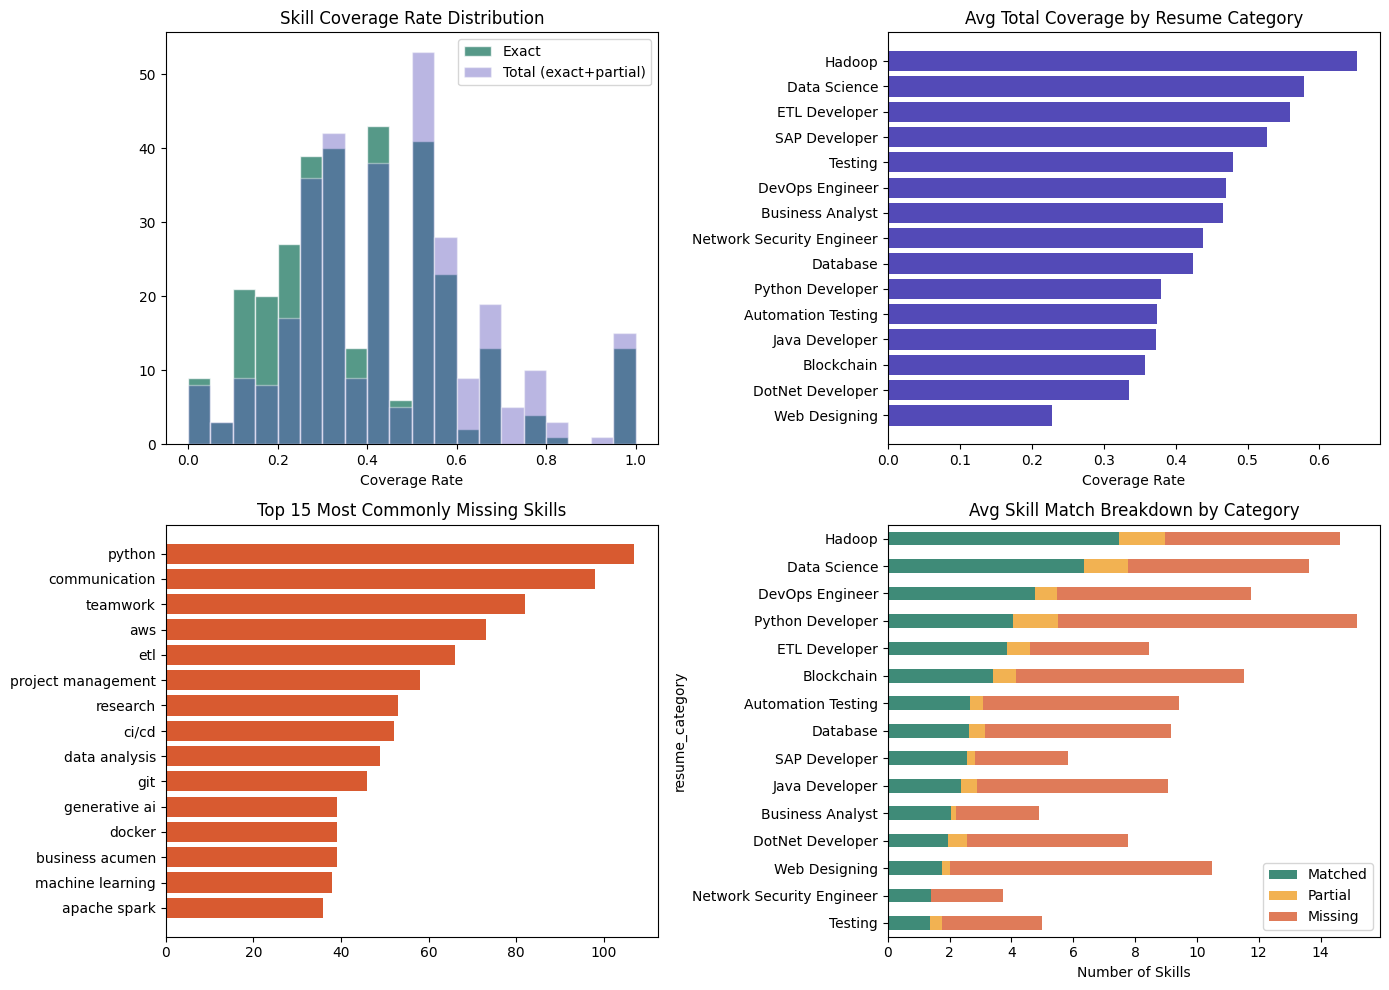

In [6]:
# ============================================================
# 4. Gap Analysis Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4a. Coverage rate distribution
axes[0, 0].hist(analysis_df['coverage_rate'], bins=20, color='#0F6E56', alpha=0.7,
                edgecolor='white', label='Exact')
axes[0, 0].hist(analysis_df['total_coverage_rate'], bins=20, color='#534AB7', alpha=0.4,
                edgecolor='white', label='Total (exact+partial)')
axes[0, 0].set_title('Skill Coverage Rate Distribution')
axes[0, 0].set_xlabel('Coverage Rate')
axes[0, 0].legend()

# 4b. Coverage by resume category
cat_coverage = analysis_df.groupby('resume_category')['total_coverage_rate'].mean().sort_values()
axes[0, 1].barh(cat_coverage.index, cat_coverage.values, color='#534AB7')
axes[0, 1].set_title('Avg Total Coverage by Resume Category')
axes[0, 1].set_xlabel('Coverage Rate')

# 4c. Most commonly missing skills
all_missing = []
for a in all_analyses:
    for m in a['missing']:
        all_missing.append(m['skill'])
missing_freq = Counter(all_missing).most_common(15)
axes[1, 0].barh([s[0] for s in missing_freq], [s[1] for s in missing_freq], color='#D85A30')
axes[1, 0].set_title('Top 15 Most Commonly Missing Skills')
axes[1, 0].invert_yaxis()

# 4d. Match type breakdown (stacked bar by category)
cat_breakdown = analysis_df.groupby('resume_category').agg({
    'num_matched': 'mean',
    'num_partial': 'mean',
    'num_missing': 'mean',
}).sort_values('num_matched', ascending=True)

cat_breakdown.plot(kind='barh', stacked=True, ax=axes[1, 1],
                   color=['#0F6E56', '#EF9F27', '#D85A30'], alpha=0.8)
axes[1, 1].set_title('Avg Skill Match Breakdown by Category')
axes[1, 1].set_xlabel('Number of Skills')
axes[1, 1].legend(['Matched', 'Partial', 'Missing'], loc='lower right')

plt.tight_layout()
plt.savefig('outputs/04_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


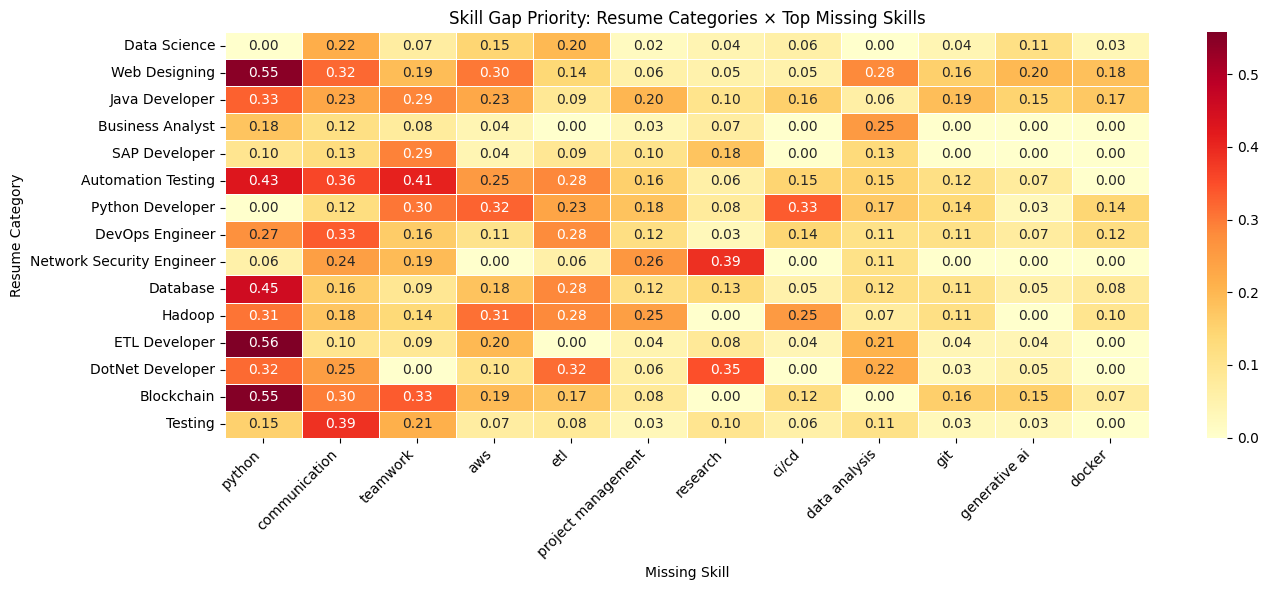

In [7]:
# ============================================================
# 5. Skill Priority Heatmap (Top Missing Skills × Categories)
# ============================================================

# Build a matrix: resume_category × top_missing_skill → avg priority
top_missing_skills = [s for s, _ in Counter(all_missing).most_common(12)]
categories = analysis_df['resume_category'].unique()

priority_matrix = np.zeros((len(categories), len(top_missing_skills)))

for a in all_analyses:
    cat_idx = list(categories).index(a['resume_category'])
    for m in a['missing']:
        if m['skill'] in top_missing_skills:
            skill_idx = top_missing_skills.index(m['skill'])
            priority_matrix[cat_idx, skill_idx] += m['priority_score']

# Normalize by count
for i in range(len(categories)):
    cat_count = (analysis_df['resume_category'] == categories[i]).sum()
    if cat_count > 0:
        priority_matrix[i] /= cat_count

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(priority_matrix, xticklabels=top_missing_skills, yticklabels=categories,
            cmap='YlOrRd', annot=True, fmt='.2f', ax=ax, linewidths=0.5)
ax.set_title('Skill Gap Priority: Resume Categories × Top Missing Skills')
ax.set_xlabel('Missing Skill')
ax.set_ylabel('Resume Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/04_priority_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# ============================================================
# 6. Save Gap Analysis Results
# ============================================================

analysis_df.to_csv('data/processed/gap_analysis_summary.csv', index=False)

with open('data/processed/gap_analysis_full.pkl', 'wb') as f:
    pickle.dump(all_analyses, f)

# Save the analyzer for the demo notebook
with open('models/skill_gap_analyzer.pkl', 'wb') as f:
    pickle.dump(analyzer, f)

print("✅ Gap analysis results saved!")
print(f"  data/processed/gap_analysis_summary.csv")
print(f"  data/processed/gap_analysis_full.pkl")
print(f"  models/skill_gap_analyzer.pkl")
print(f"\n{'='*60}")
print("PHASE 3a COMPLETE — Ready for Notebook 05: Baseline Classifiers")
print(f"{'='*60}")


✅ Gap analysis results saved!
  data/processed/gap_analysis_summary.csv
  data/processed/gap_analysis_full.pkl
  models/skill_gap_analyzer.pkl

PHASE 3a COMPLETE — Ready for Notebook 05: Baseline Classifiers
